In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import keras
import tensorflow as tf
from keras import models, layers, optimizers, callbacks, regularizers, initializers
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, f1_score, classification_report

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
2026-06-08 17:29:32.129867: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("../1.DATASET/CMI_FINAL_OD.csv")

In [3]:
column2drop = ['id']

df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")

X shape : (8396, 17)
y shape : (8396,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5801, 1.0: 1570, 2.0: 941, 3.0: 84}


# Classifier training

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, 
                                                    random_state=0, 
                                                    shuffle=True, 
                                                    stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size=0.2, 
                                                  random_state=0, 
                                                  shuffle=True, 
                                                  stratify=y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [5]:
print(f"X shape : {X_test.shape}")

X shape : (1680, 17)


In [6]:
base_clf = XGBClassifier(
    objective='multi:softprob',   
    num_class=4,
    tree_method='hist',           
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    colsample_bytree = 0.9618032508488761,
    gamma = 0,
    learning_rate =  0.01,
    max_depth =  7,
    max_leaves = 0,
    min_child_weight = 8,
    n_estimators = 500,
    reg_alpha = 0.01,
    reg_lambda = 0.001,
    subsample = 0.8489131066246972

)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

base_clf.fit(
    X_train_scaled, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val_scaled, y_val)],  # opzionale ma utile
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9618032508488761, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=0,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=4,
              num_parallel_tree=None, ...)

In [7]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("XGB Feature Importances")

    plt.show()

In [8]:

y_pred = base_clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 per classe:", f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy: 0.5488095238095239
F1 per classe: [0.71520737 0.24962406 0.25154639 0.1       ]
              precision    recall  f1-score   support

         0.0       0.77      0.67      0.72      1161
         1.0       0.24      0.26      0.25       314
         2.0       0.21      0.32      0.25       188
         3.0       0.09      0.12      0.10        17

    accuracy                           0.55      1680
   macro avg       0.32      0.34      0.33      1680
weighted avg       0.60      0.55      0.57      1680



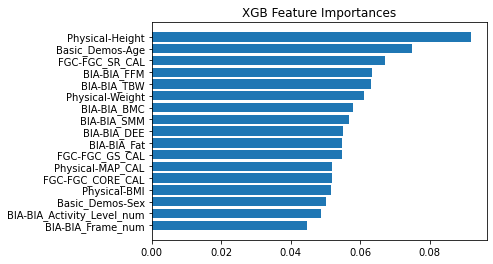

In [9]:
feature_imp(base_clf, attributes)

# Global methods (TREPAN)

In [10]:

# ── Approccio 2: surrogate addestrato su X_train+X_val ────
# fit su train+val, evaluate SEMPRE su X_test
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval_pred = base_clf.predict(X_trainval)  # oracolo

surrogate_big = DecisionTreeClassifier(max_depth=7, min_samples_leaf=5, random_state=42)
surrogate_big.fit(X_trainval, y_trainval_pred)

# test set identico per entrambi
y_pred_xgb_test = base_clf.predict(X_test_scaled)  # oracolo su test
fidelity_big = accuracy_score(y_pred_xgb_test, surrogate_big.predict(X_test_scaled))
print(f"Fidelity (train+val → test): {fidelity_big:.4f}")

Fidelity (train+val → test): 0.7464


In [11]:
from sklearn.tree._tree import TREE_LEAF

def is_leaf(inner_tree, index):
    # Check whether node is leaf node
    return (inner_tree.children_left[index] == TREE_LEAF and
            inner_tree.children_right[index] == TREE_LEAF)


def prune_index(inner_tree, decisions, index=0):
    # Start pruning from the bottom - if we start from the top, we might miss
    # nodes that become leaves during pruning.
    # Do not use this directly - use prune_duplicate_leaves instead.
    if not is_leaf(inner_tree, inner_tree.children_left[index]):
        prune_index(inner_tree, decisions, inner_tree.children_left[index])
    if not is_leaf(inner_tree, inner_tree.children_right[index]):
        prune_index(inner_tree, decisions, inner_tree.children_right[index])

    # Prune children if both children are leaves now and make the same decision:
    if (is_leaf(inner_tree, inner_tree.children_left[index]) and
        is_leaf(inner_tree, inner_tree.children_right[index]) and
        (decisions[index] == decisions[inner_tree.children_left[index]]) and
        (decisions[index] == decisions[inner_tree.children_right[index]])):
        # turn node into a leaf by "unlinking" its children
        inner_tree.children_left[index] = TREE_LEAF
        inner_tree.children_right[index] = TREE_LEAF
        # print("Pruned {}".format(index))


def prune_duplicate_leaves(dt):
    # Remove leaves if both
    decisions = dt.tree_.value.argmax(axis=2).flatten().tolist()  # Decision for each node
    prune_index(dt.tree_, decisions)

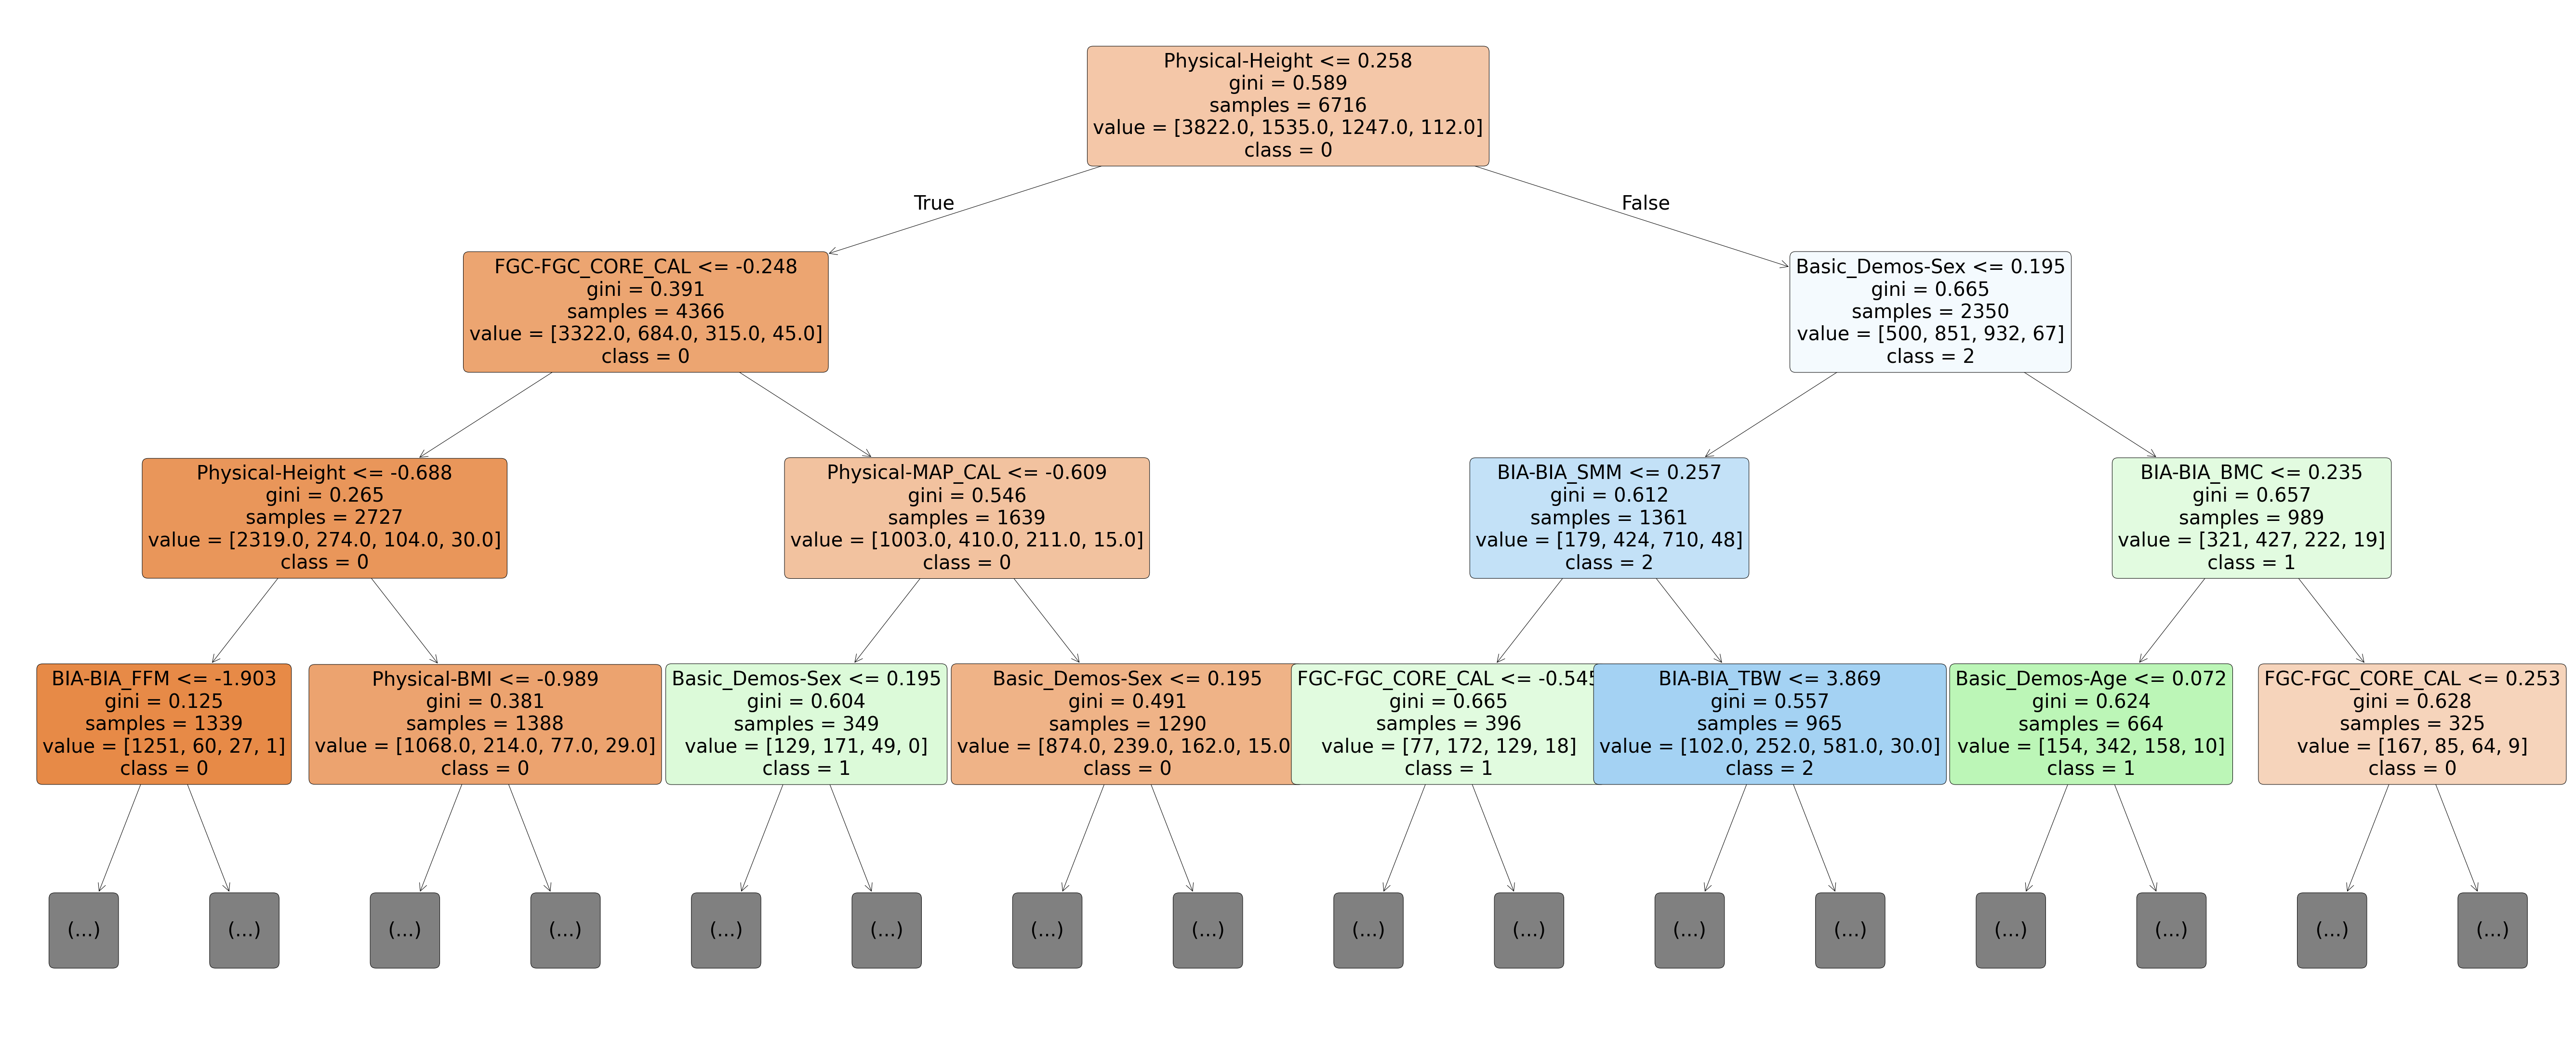

In [42]:
plt.figure(figsize=(75, 30))

prune_duplicate_leaves(surrogate_big)

plot_tree(surrogate_big, 
          feature_names=attributes, 
          class_names=['0', '1', '2', '3'], 
          filled=True, 
          rounded=True,
          fontsize=40,
          max_depth=3)
#plt.savefig('./img/XAI/decision_tree.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

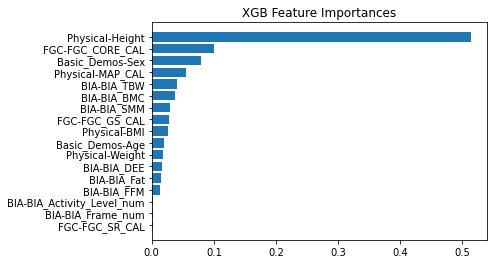

In [13]:
feature_imp(surrogate_big, attributes)

# Local methods

## SHAP

In [49]:
import shap
shap.initjs()

In [50]:
misclassified_mask = (y_test != y_pred)
misclassified_scaled = X_test_scaled[misclassified_mask]
correct_scaled       = X_test_scaled[~misclassified_mask]

# Tieni anche i non-scalati per interpretabilità (es. SHAP in feature space originale)
misclassified = X_test[misclassified_mask]
correct       = X_test[~misclassified_mask]

# 5. Verifica predizioni — ora avranno senso
print('Misclassified[0] → pred:', base_clf.predict(misclassified_scaled[0].reshape(1,-1)),
      '| true:', y_test[misclassified_mask][0])
print('Misclassified[1] → pred:', base_clf.predict(misclassified_scaled[1].reshape(1,-1)),
      '| true:', y_test[misclassified_mask][1])
print('Correct[0]  → pred:', base_clf.predict(correct_scaled[0].reshape(1,-1)),
      '| true:', y_test[~misclassified_mask][0])
print('Correct[10] → pred:', base_clf.predict(correct_scaled[10].reshape(1,-1)),
      '| true:', y_test[~misclassified_mask][10])

Misclassified[0] → pred: [1] | true: 0.0
Misclassified[1] → pred: [1] | true: 0.0
Correct[0]  → pred: [0] | true: 0.0
Correct[10] → pred: [0] | true: 0.0


In [51]:
x1 = misclassified_scaled[0]
x2 = misclassified_scaled[1]

x3 = correct_scaled[0]
x4 = correct_scaled[10]

X = np.array([x1, x2, x3, x4])

In [55]:
instances = {}

for cls in range(4):

    correct_mask_cls = (~misclassified_mask) & (y_test == cls)
    misclassified_mask_cls = misclassified_mask & (y_test == cls)

    # scaled
    correct_cls_scaled = X_test_scaled[correct_mask_cls]
    misclassified_cls_scaled = X_test_scaled[misclassified_mask_cls]

    # original
    correct_cls_original = X_test[correct_mask_cls]
    misclassified_cls_original = X_test[misclassified_mask_cls]

    if correct_cls_scaled.shape[0] == 0 or misclassified_cls_scaled.shape[0] == 0:
        continue

    instances[cls] = {

        # scaled (per SHAP)
        'correct': correct_cls_scaled[0],
        'misclassified': misclassified_cls_scaled[0],

        'correct_original': correct_cls_original[0],
        'misclassified_original': misclassified_cls_original[0],

        'true_label': cls
    }
    
    print(f"  ✅ Correct     → pred: {instances[cls]['correct']}  | true: {cls}")
    print(f"  ❌ Misclassified → pred: {instances[cls]['misclassified']} | true: {cls}")

# ── Assembla X per SHAP ───────────────────────────────────
X_shap = np.array([
    instances[cls][kind]
    for cls in sorted(instances.keys())
    for kind in ['correct', 'misclassified']
])

labels_shap = [
    f"Class {cls} — {'correct' if kind == 'correct' else 'misclassified'}"
    for cls in sorted(instances.keys())
    for kind in ['correct', 'misclassified']
]

print(f"\nX_shap shape: {X_shap.shape}")  # atteso (8, n_features)
for i, label in enumerate(labels_shap):
    print(f"  [{i}] {label}")

  ✅ Correct     → pred: [-1.1912309  -0.82354451 -1.0875689  -1.02077368 -1.05918852 -0.37837519
 -1.18095023 -0.28928472  3.00808157 -2.1375336  -0.92697799 -1.4757516
 -0.88440135 -0.96219605 -1.28701759 -1.18149487 -1.01244931]  | true: 0
  ❌ Misclassified → pred: [-0.06815396  1.21426346 -0.67072187  1.16508078  0.2115308  -0.10513511
 -0.07061914 -1.46513596 -1.68641625 -0.9271583  -0.8244242  -0.58663451
  0.56601041 -0.5326739   0.4853122  -0.64458959 -0.00721597] | true: 0
  ✅ Correct     → pred: [-0.62969243  1.21426346 -0.51540748 -0.43666767 -0.57468344  0.40719003
 -0.42965015 -0.30528168  0.12605383  1.49359231 -0.64989471  0.52813438
 -0.43707151 -0.6016881  -1.28701759 -0.49639877 -0.15435212]  | true: 1
  ❌ Misclassified → pred: [-1.47200013  1.21426346  0.02031634 -0.17446898 -0.19287159  2.33694808
 -0.39179701 -0.42418049  1.77268741  0.28321701  0.46260972 -0.74318015
 -0.15987445 -0.17738684  0.4853122   0.2926291  -0.12925089] | true: 1
  ✅ Correct     → pred: [ 1

In [57]:
for cls in instances:

    print(f"\n{'='*60}")
    print(f"CLASS {cls}")
    print(f"{'='*60}")

    print("\nCorrect instance:")
    print(
        pd.Series(
            instances[cls]['correct_original'],
            index=attributes,
            name="Value"
        )
    )

    print("\nMisclassified instance:")
    print(
        pd.Series(
            instances[cls]['misclassified_original'],
            index=attributes,
            name="Value"
        )
    )


CLASS 0

Correct instance:
Basic_Demos-Age                  6.000000
Basic_Demos-Sex                  0.000000
Physical-BMI                    14.644277
Physical-Height                 48.500000
Physical-Weight                 49.000000
Physical-MAP_CAL                81.000000
FGC-FGC_CORE_CAL                 2.000000
FGC-FGC_GS_CAL                  18.613018
FGC-FGC_SR_CAL                  14.500000
BIA-BIA_Activity_Level_num       1.000000
BIA-BIA_BMC                      2.803430
BIA-BIA_DEE                   1236.940000
BIA-BIA_FFM                     43.609730
BIA-BIA_Fat                      5.390270
BIA-BIA_Frame_num                1.000000
BIA-BIA_SMM                     16.031600
BIA-BIA_TBW                     30.717400
Name: Value, dtype: float64

Misclassified instance:
Basic_Demos-Age                 10.000000
Basic_Demos-Sex                  1.000000
Physical-BMI                    16.446694
Physical-Height                 65.340000
Physical-Weight                 99.88

Number of classes: 8
Shape per class: (17, 4)


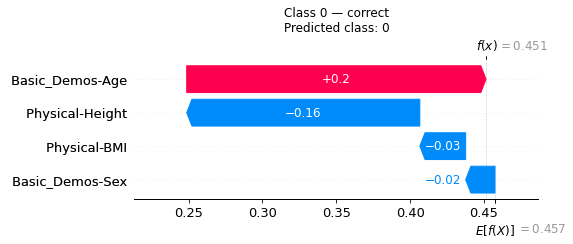

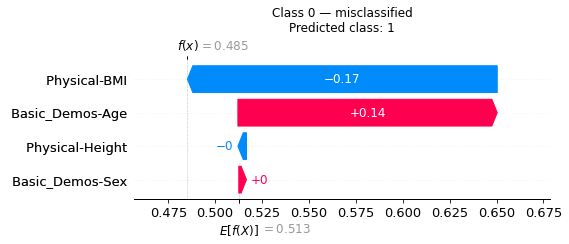

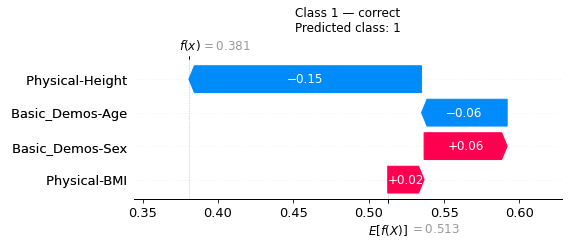

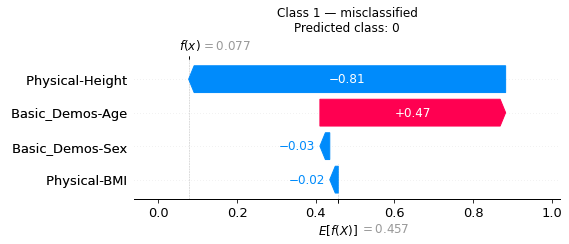

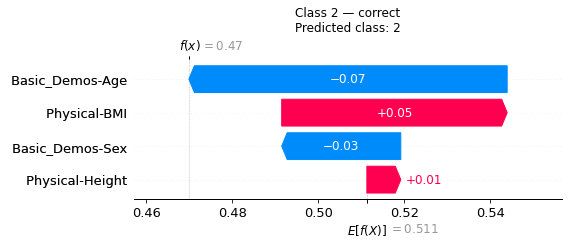

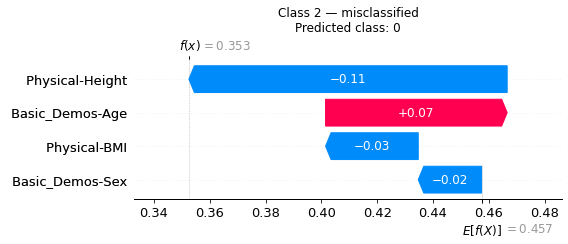

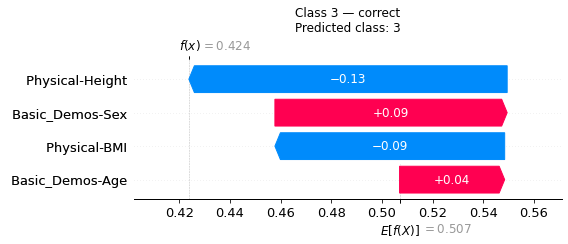

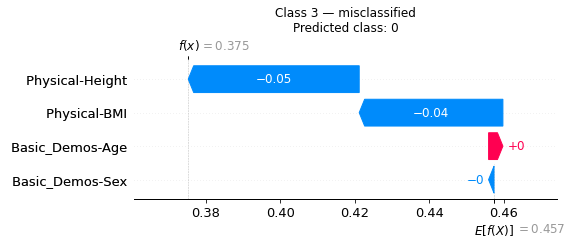

In [ ]:
import shap

# ── Explainer ottimizzato per tree-based models ───────────
explainer = shap.TreeExplainer(base_clf)

# shap_values è lista di 4 array, shape (n_samples, n_features)
shap_values = explainer.shap_values(X_shap)

print(f"Number of classes: {len(shap_values)}")
print(f"Shape per class: {shap_values[0].shape}")  # (8, n_features)

# ── Waterfall per ogni istanza ────────────────────────────
for i, label in enumerate(labels_shap):
    
    # la classe predetta per questa istanza
    pred_class = base_clf.predict(X_shap[i].reshape(1,-1))[0]
    
    # usiamo i shap values della classe predetta dal modello
    sv   = shap_values[pred_class][i]
    ev   = explainer.expected_value[pred_class]
    
    shap.plots._waterfall.waterfall_legacy(
        ev,
        sv,
        features=X_shap[i],
        feature_names=attributes,
        max_display=10,
        show=False
    )
    plt.gcf().set_facecolor('white')
    plt.title(f'{label}\nPredicted class: {pred_class}')
    plt.tight_layout()
    #plt.savefig(f'./img/XAI/shap_{i}_{label.replace(" ", "_")}.png',
                #dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
instances = {}

for cls in range(4):

    correct_mask_cls = (~misclassified_mask) & (y_test == cls)
    misclassified_mask_cls = misclassified_mask & (y_test == cls)

    # scaled
    correct_cls_scaled = X_test_scaled[correct_mask_cls]
    misclassified_cls_scaled = X_test_scaled[misclassified_mask_cls]

    # original
    correct_cls_original = X_test[correct_mask_cls]
    misclassified_cls_original = X_test[misclassified_mask_cls]

    if correct_cls_scaled.shape[0] == 0 or misclassified_cls_scaled.shape[0] == 0:
        continue

    instances[cls] = {

        # scaled (per SHAP)
        'correct': correct_cls_scaled[0],
        'misclassified': misclassified_cls_scaled[0],

        # original values
        'correct_original': correct_cls_original.iloc[0],
        'misclassified_original': misclassified_cls_original.iloc[0],

        'true_label': cls
    }